# ---------------------------------------------------
# Advanced Apex Project: Real Estate Price Prediction
# Team: The Outliers
# ---------------------------------------------------

## Phase 2 : Preprocessing and Feature Engineering

In [128]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

sns.set(style='whitegrid')

In [129]:
# Load dataset
file_path = "./data/AmesHousing.csv"   # ensure this file exists in your project folder
df = pd.read_csv(file_path)

In [130]:
# Basic inspection
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist()[:10], "...")
print("\nFirst 5 rows:")
display(df.head())



Dataset shape: (2930, 82)

Columns: ['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour'] ...

First 5 rows:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [131]:
# Data types and non-null counts
print("\nData Types and Non-Null Counts:")
print(df.info())



Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-n

In [132]:
# Quick statistics (numeric columns)
print("\nSummary statistics (numeric features):")
display(df.describe().T.head(10))


Summary statistics (numeric features):


,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [133]:
# Missing values overview
print("\nMissing values (top 15 features with NaNs):")
print(df.isnull().sum().sort_values(ascending=False).head(15))


Missing values (top 15 features with NaNs):
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
dtype: int64


In [134]:
# Histogram of Target Variable (SalePrice)

### `.describe()`
The `.describe()` method provides descriptive statistics for all numerical columns, including count, mean, standard deviation, min/max, and quartiles.

In [135]:
# Generate descriptive statistics for numerical columns
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


### `.quantile()`
If you need specific quantiles (percentiles) beyond the ones provided by `.describe()`, you can use the `.quantile()` method.

In [136]:
# Calculate the 10th, 50th (median), and 90th quantiles for 'SalePrice'
price_quantiles = df['SalePrice'].quantile([0.1, 0.5, 0.9])

print("SalePrice Quantiles:")
print(price_quantiles)

SalePrice Quantiles:
0.1    105450.0
0.5    160000.0
0.9    281241.7
Name: SalePrice, dtype: float64


##Categorical Data Analysis with `.value_counts()`

To understand the distribution of categorical variables, `.value_counts()` is extremely useful. It returns a series containing counts of unique values.

In [137]:
# Get the number of houses in each neighborhood
neighborhood_counts = df['Neighborhood'].value_counts()

print("Number of houses per neighborhood:")
print(neighborhood_counts.head(10)) # Display top 10

Number of houses per neighborhood:
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Name: count, dtype: int64


##Correlation Analysis

Correlation measures the linear relationship between two variables. It ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation). A value near 0 indicates no linear correlation. This is crucial for feature selection in a prediction model.

In [138]:
# Calculate the correlation matrix for all numerical columns
# The 'numeric_only=True' argument is important to avoid errors with non-numeric columns
correlation_matrix = df.corr(numeric_only=True)

# To make this more readable, let's see which features correlate most strongly with 'SalePrice'
saleprice_correlation = correlation_matrix['SalePrice'].sort_values(ascending=False)

print("Top 10 features most positively correlated with SalePrice:")
print(saleprice_correlation.head(11)) # a variable is always 100% correlated with itself

print("\nTop 5 features most negatively correlated with SalePrice:")
print(saleprice_correlation.tail(5))

Top 10 features most positively correlated with SalePrice:
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64

Top 5 features most negatively correlated with SalePrice:
MS SubClass      -0.085092
Overall Cond     -0.101697
Kitchen AbvGr    -0.119814
Enclosed Porch   -0.128787
PID              -0.246521
Name: SalePrice, dtype: float64


##Slicing and Dicing (Data Subsetting)

Slicing and dicing involves selecting specific rows and columns to isolate a subset of the data for analysis. We typically use `.loc[]` for label-based indexing and `.iloc[]` for position-based indexing.

### Column Selection

In [139]:
# Select a few specific columns to create a smaller DataFrame
subset_df = df[['Lot Area', 'Neighborhood', 'Year Built', 'Overall Qual', 'SalePrice']]
subset_df.head()

,Lot Area,Neighborhood,Year Built,Overall Qual,SalePrice
0,31770,NAmes,1960,6,215000
1,11622,NAmes,1961,5,105000
2,14267,NAmes,1958,6,172000
3,11160,NAmes,1968,7,244000
4,13830,Gilbert,1997,5,189900


### Row Selection with Conditions using `.loc`

In [140]:
# Select all houses built after the year 2000
modern_houses = df.loc[df['Year Built'] > 2000]

print(f"Number of houses built after 2000: {len(modern_houses)}")
modern_houses[['Year Built', 'SalePrice']].head()

Number of houses built after 2000: 735


,Year Built,SalePrice
6,2001,213500
15,2003,538000
17,2010,394432
36,2009,376162
37,2007,306000


In [141]:
# You can also combine multiple conditions.
# Let's find houses with an 'Overall Qual' of 8 or more that sold for less than $200,000
high_quality_bargains = df.loc[(df['Overall Qual'] >= 8) & (df['SalePrice'] < 200000)]

print(f"Number of high-quality bargain houses: {len(high_quality_bargains)}")
high_quality_bargains[['Overall Qual', 'SalePrice', 'Neighborhood']].head()

Number of high-quality bargain houses: 40


,Overall Qual,SalePrice,Neighborhood
7,8,191500,StoneBr
16,8,164000,Gilbert
53,8,192000,Blmngtn
106,8,155000,Greens
183,8,150000,OldTown


##Roll-up (Grouping and Aggregation)

"Rolling up" data usually means grouping it by some category and then calculating an aggregate statistic for each group (like a sum, mean, or count). This is done with the `.groupby()` method.

In [142]:
# Let's find the average SalePrice for each neighborhood
avg_price_by_neighborhood = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).round(2)

print("Average Sale Price by Neighborhood:")
print(avg_price_by_neighborhood.head(10))

Average Sale Price by Neighborhood:
Neighborhood
NoRidge    330319.13
StoneBr    324229.20
NridgHt    322018.27
GrnHill    280000.00
Veenker    248314.58
Timber     246599.54
Somerst    229707.32
ClearCr    208662.09
Crawfor    207550.83
CollgCr    201803.43
Name: SalePrice, dtype: float64


###Univariate Analysis

Here, we analyze individual variables to understand their distributions.

#### Distribution of the Target Variable (`SalePrice`)
Let's start by looking at our target variable. A histogram and a Kernel Density Estimate (KDE) plot are perfect for this.

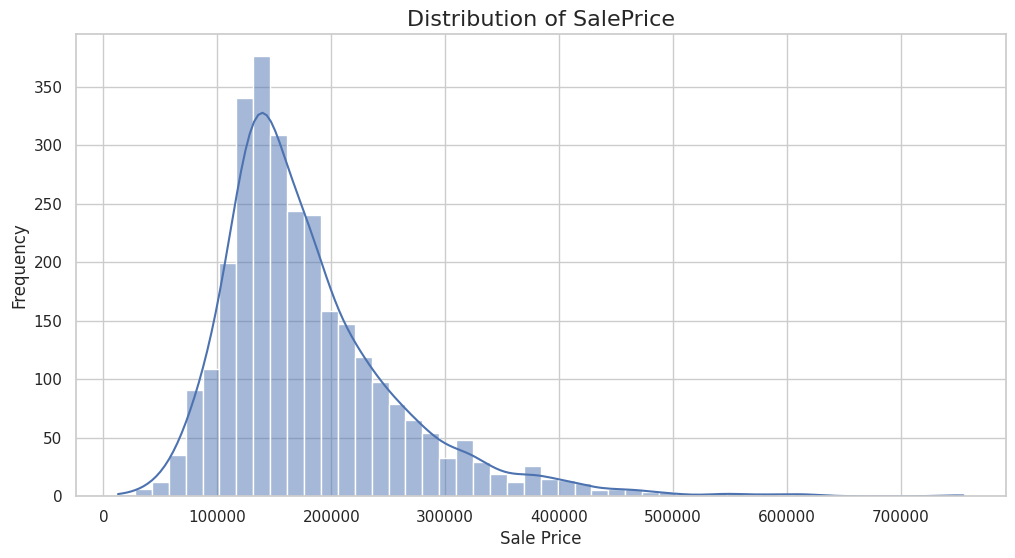

In [143]:
plt.figure(figsize=(12, 6))
sns.histplot(df['SalePrice'], kde=True, bins=50)
plt.title('Distribution of SalePrice', fontsize=16)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

# We can see the target variable is right-skewed.
# A log transformation is often useful in this case for modeling.


#### Distribution of Categorical Features
A bar plot (or count plot) is ideal for visualizing the frequency of each category in a categorical variable.

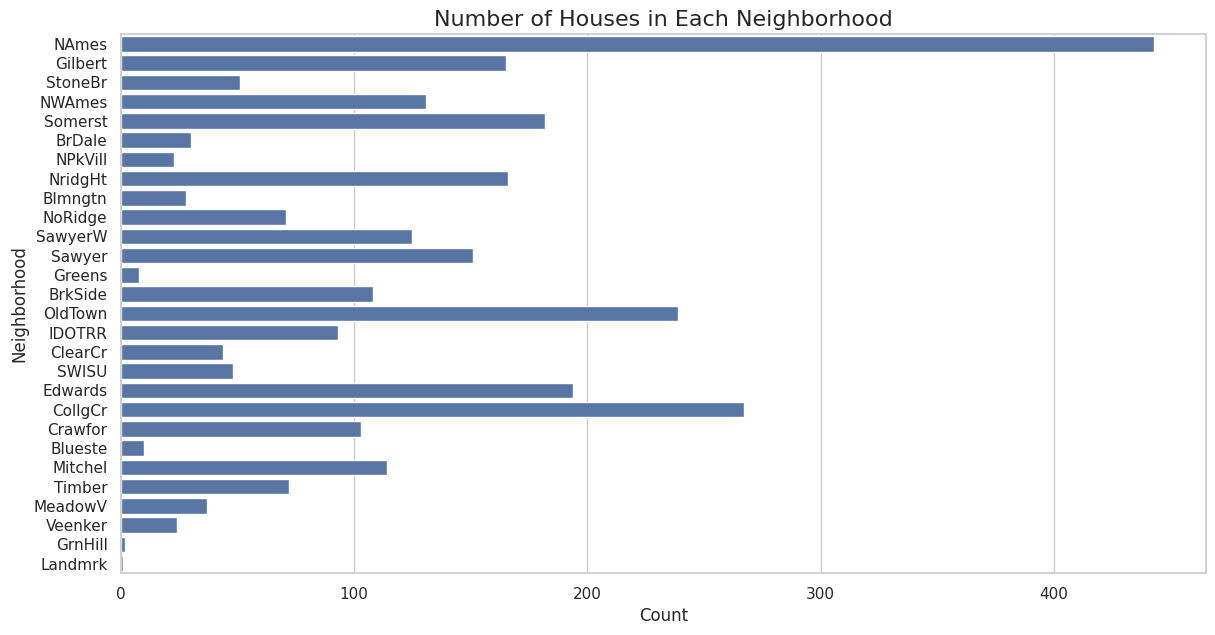

In [144]:
plt.figure(figsize=(14, 7))
sns.countplot(y=df['Neighborhood'])
plt.title('Number of Houses in Each Neighborhood', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Neighborhood')
plt.show()

###Bivariate Analysis

Now, let's explore the relationship between two variables.

#### Scatter Plot (Numeric vs. Numeric)
A scatter plot is the best way to visualize the relationship between two numeric variables. We'll check the relationship between `Gr Liv Area` (Above Ground Living Area) and `SalePrice`.

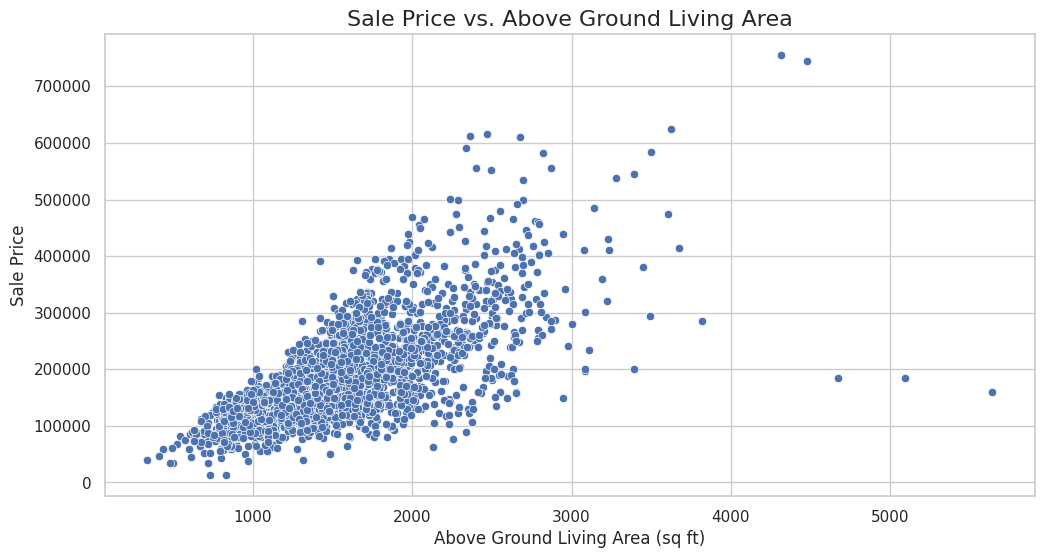

In [145]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['Gr Liv Area'], y=df['SalePrice'])
plt.title('Sale Price vs. Above Ground Living Area', fontsize=16)
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

# We can see a strong positive linear relationship. There are also a couple of outliers.

#### Box Plot (Categorical vs. Numeric)
Box plots are excellent for comparing the distribution of a numeric variable across different categories of a categorical variable. Let's see how `Overall Qual` (Overall Quality) affects `SalePrice`.

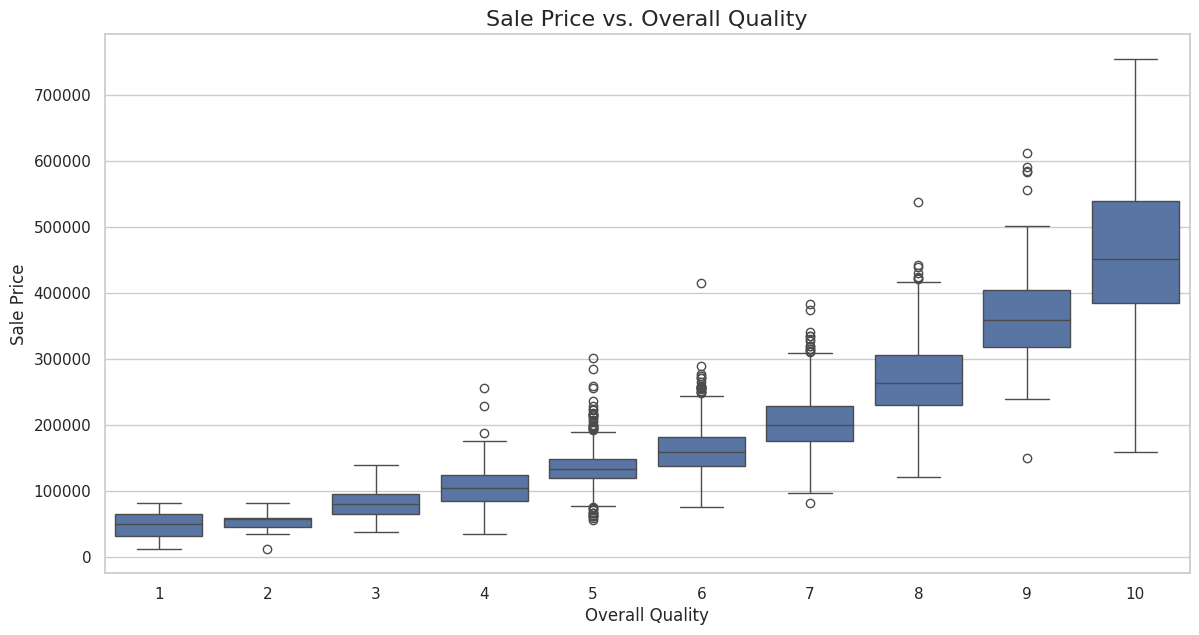

In [146]:
plt.figure(figsize=(14, 7))
sns.boxplot(x=df['Overall Qual'], y=df['SalePrice'])
plt.title('Sale Price vs. Overall Quality', fontsize=16)
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.show()

# As expected, higher overall quality corresponds to a higher sale price.

#### Crosstabs (Categorical vs. Categorical)
A crosstab (or contingency table) is used to analyze the relationship between two or more categorical variables.

In [147]:
pd.crosstab(df['Bldg Type'], df['House Style'])

House Style,1.5Fin,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl
Bldg Type,,,,,,,,
1Fam,289,18,1222,7,18,703,48,120
2fmCon,19,1,16,1,4,18,2,1
Duplex,5,0,57,0,2,25,19,1
Twnhs,1,0,19,0,0,71,6,4
TwnhsE,0,0,167,0,0,56,8,2


###Multivariate Analysis

Here we investigate the relationships among three or more variables.

#### Correlation Heatmap
A correlation heatmap is a powerful tool to visualize the correlation between all numeric variables. It helps us quickly identify which features are most related to the target variable (`SalePrice`).

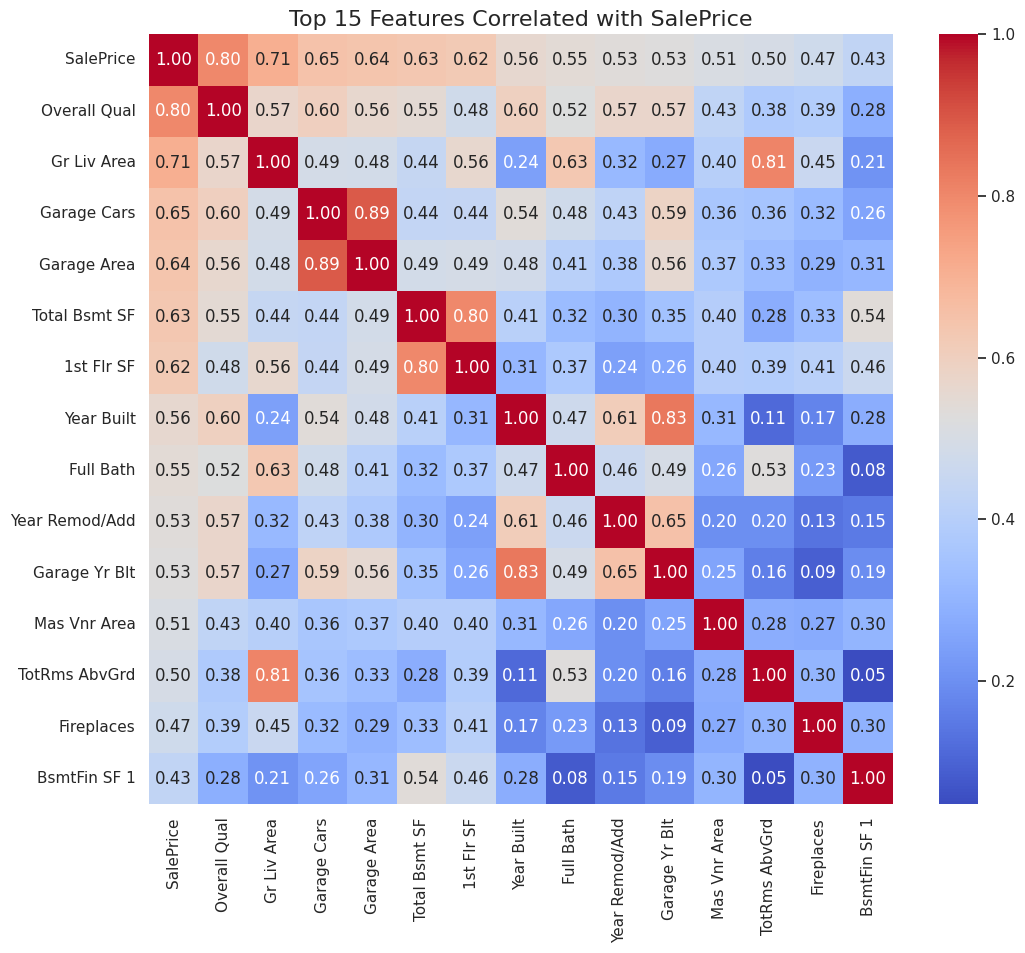

In [148]:
# First, we calculate the correlation matrix for all numeric columns.
corr_matrix = df.corr(numeric_only=True)

# To make the heatmap readable, let's select the top N features most correlated with SalePrice
n = 15 # number of features
top_n_cols = corr_matrix.nlargest(n, 'SalePrice')['SalePrice'].index
top_n_corr_matrix = df[top_n_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top_n_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'Top {n} Features Correlated with SalePrice', fontsize=16)
plt.show()

#### Pair Plots

A pair plot allows us to see both the distribution of single variables and relationships between two variables. It's a great tool but can be computationally expensive for datasets with many features.

**Note:** We will create a pair plot for a small subset of the most important features to avoid long computation times.

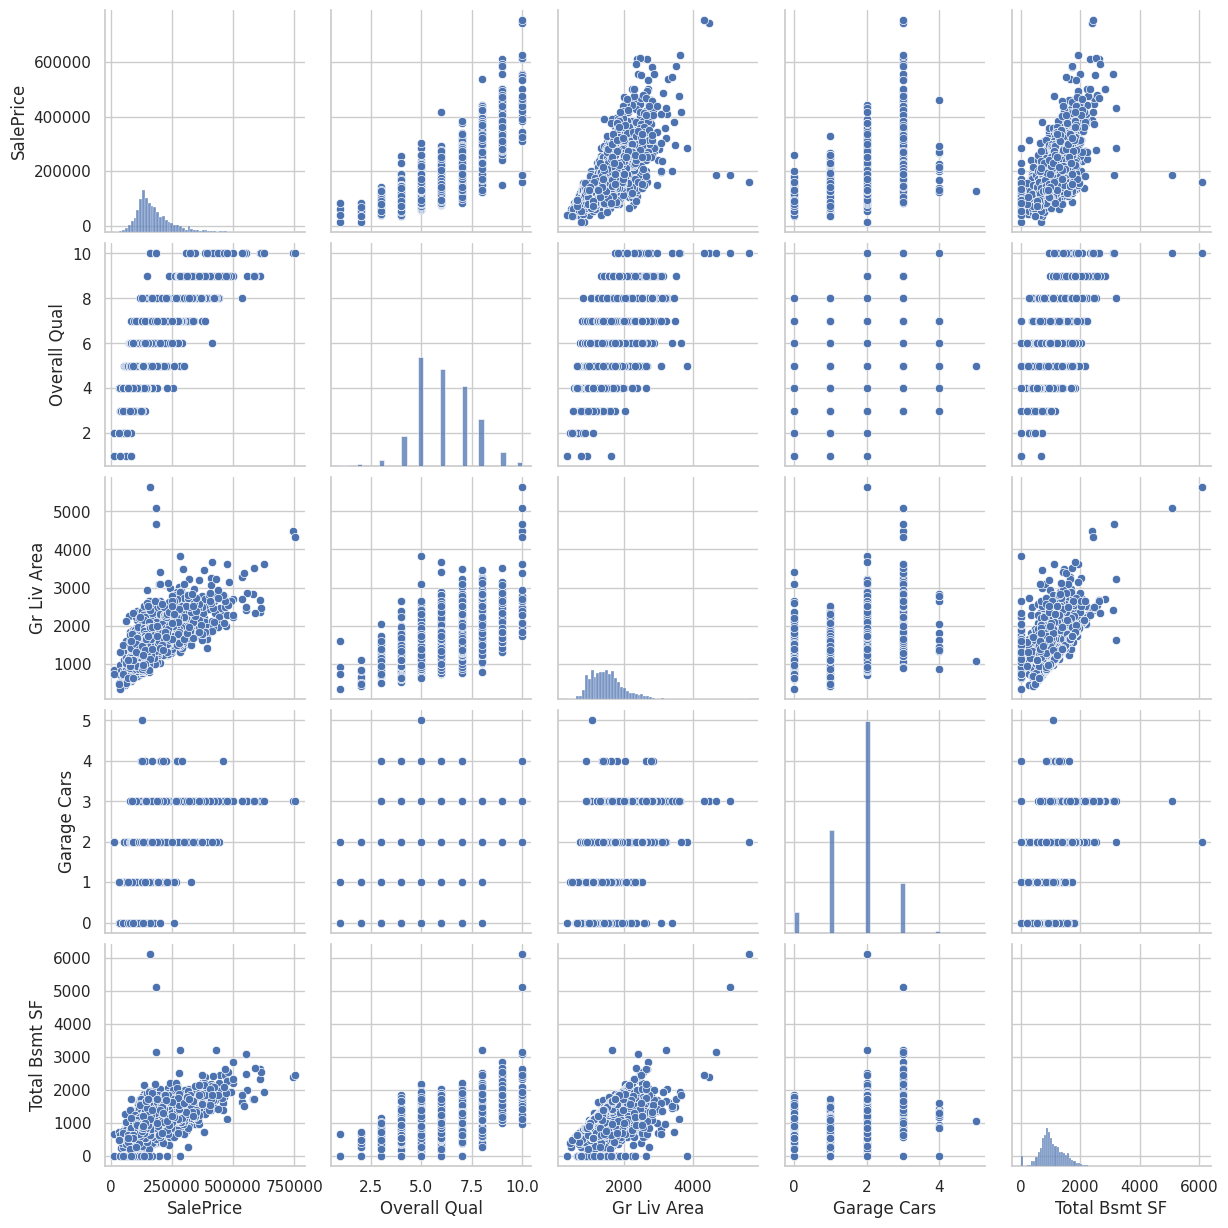

In [149]:
# Select a few key features for the pair plot
pairplot_cols = ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF']

# Create the pair plot
sns.pairplot(df[pairplot_cols], height=2.5)
plt.show()

In [150]:
# You can also perform multiple aggregations at once using .agg()
# Let's group by 'Overall Qual' and find the mean, median, standard deviation, and count of 'SalePrice' for each quality level.

quality_rollup = df.groupby('Overall Qual')['SalePrice'].agg(['mean', 'median', 'count', 'std']).round(2)

print("SalePrice Statistics by Overall Quality:")
print(quality_rollup)

SalePrice Statistics by Overall Quality:
                   mean    median  count        std
Overall Qual                                       
1              48725.00   50150.0      4   29341.94
2              52325.31   57625.0     13   17562.96
3              83185.98   81200.0     40   23569.80
4             106485.10  105000.0    226   29224.94
5             134752.52  133000.0    825   27690.60
6             162130.32  159500.0    732   37201.30
7             205025.76  200000.0    602   43166.27
8             270913.59  264530.5    350   61326.21
9             368336.77  360000.0    107   79201.27
10            450217.32  451950.0     31  141975.97


### Drop Irrelevant Columns

**Justification:** Columns like `Order` and `PID` (Property ID) are identifiers. They don't provide any predictive information about the house price and should be removed.

In [151]:
irrelevant_cols = ['Order', 'PID']
# Initialize df_cleaned with the original dataframe
df_cleaned = df.copy()
df_cleaned = df_cleaned.drop(columns=irrelevant_cols)

print(f"Dropped columns: {irrelevant_cols}")
print(f"New shape: {df_cleaned.shape}")

Dropped columns: ['Order', 'PID']
New shape: (2930, 80)


### Drop Columns with Too Many Missing Values

**Justification:** Some columns are missing a very large percentage of their data (e.g., > 80%). Imputing them would add more noise than signal. The data dictionary for Ames reveals that `NA` in columns like `Alley`, `Pool QC`, `Fence`, and `Misc Feature` actually means "No Alley Access", "No Pool", etc. However, since the *vast majority* are "No", these columns have very low variance and are often dropped to simplify the model.

Let's set a threshold of 80% missing values to drop a column.

In [152]:
# Calculate the percentage of missing values for each column
missing_percentage = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

# Sort and display columns with missing values
print("Columns with missing values (%):")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


Columns with missing values (%):
Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64


In [153]:
# Define the threshold
threshold = 80
cols_to_drop = missing_percentage[missing_percentage > threshold].index

df_cleaned = df_cleaned.drop(columns=cols_to_drop)

print(f"\nDropped columns with >{threshold}% missing values: {list(cols_to_drop)}")
print(f"New shape: {df_cleaned.shape}")


Dropped columns with >80% missing values: ['Alley', 'Pool QC', 'Fence', 'Misc Feature']
New shape: (2930, 76)


### Impute Missing Values

Now we handle the remaining columns with missing data.

#### Imputing Numerical Columns

**Justification:** For `Lot Frontage`, the distribution is likely skewed (a few properties have very large lot frontages). Using the **median** is more robust to outliers than the mean. For year-based columns like `Garage Yr Blt`, the **mode** (most common year) or **median** are both reasonable. Let's stick with median for numerical features.

Lot Frontage Skew: 1.499067354883421


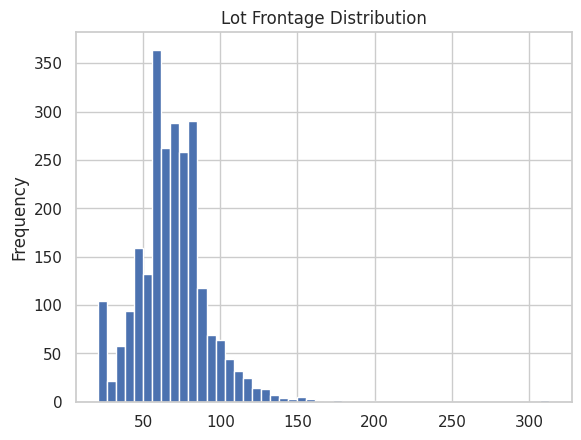

Imputed 'Lot Frontage' with median: 68.0
Imputed 'Mas Vnr Area' with median: 0.0
Imputed 'Garage Yr Blt' with median: 1979.0


In [154]:
# Let's check the skew of 'Lot Frontage' to confirm
print(f"Lot Frontage Skew: {df_cleaned['Lot Frontage'].skew()}")
df_cleaned['Lot Frontage'].plot(kind='hist', bins=50, title='Lot Frontage Distribution')
plt.show()

# The skew is high (> 1), so median is appropriate.
numerical_cols_to_impute = ['Lot Frontage', 'Mas Vnr Area', 'Garage Yr Blt']

for col in numerical_cols_to_impute:
    if col in df_cleaned.columns:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)
        print(f"Imputed '{col}' with median: {median_val}")

#### Imputing Categorical Columns

**Justification:** For categorical (object) columns, the best strategy is to fill missing values with the **mode** (most frequent value). For some columns like `Bsmt Qual`, `NA` might mean "No Basement". In that case, we could create a new category 'None'. However, a simpler and often effective approach is to use the mode.

Let's select all 'object' type columns and fill their NaNs with the mode.

In [155]:
# Get all categorical columns (dtype 'object')
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

print(f"Categorical columns with missing values:")
print(df_cleaned[categorical_cols].isnull().sum()[df_cleaned[categorical_cols].isnull().sum() > 0])

# Impute with mode
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(mode_val)
        print(f"Imputed '{col}' with mode: {mode_val}")

Categorical columns with missing values:
Mas Vnr Type      1775
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin Type 2      81
Electrical           1
Fireplace Qu      1422
Garage Type        157
Garage Finish      159
Garage Qual        159
Garage Cond        159
dtype: int64
Imputed 'Mas Vnr Type' with mode: BrkFace
Imputed 'Bsmt Qual' with mode: TA
Imputed 'Bsmt Cond' with mode: TA
Imputed 'Bsmt Exposure' with mode: No
Imputed 'BsmtFin Type 1' with mode: GLQ
Imputed 'BsmtFin Type 2' with mode: Unf
Imputed 'Electrical' with mode: SBrkr
Imputed 'Fireplace Qu' with mode: Gd
Imputed 'Garage Type' with mode: Attchd
Imputed 'Garage Finish' with mode: Unf
Imputed 'Garage Qual' with mode: TA
Imputed 'Garage Cond' with mode: TA


In [156]:
# Final check for any remaining missing values
print(f"\nTotal missing values remaining: {df_cleaned.isnull().sum().sum()}")


Total missing values remaining: 10


### Remove Duplicates

**Justification:** Duplicate rows can bias the model. We should remove them.

In [157]:
duplicates_count = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

if duplicates_count > 0:
    df_cleaned = df_cleaned.drop_duplicates()
    print("Duplicate rows removed.")
    print(f"New shape: {df_cleaned.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


### Handle Outliers

**Justification:** Outliers can disproportionately affect the performance of some models (like linear regression). We can use the **IQR (Interquartile Range)** method to identify and **cap** them. We'll focus on key numerical features like `Gr Liv Area` (Above Ground Living Area) and the target variable `SalePrice`.

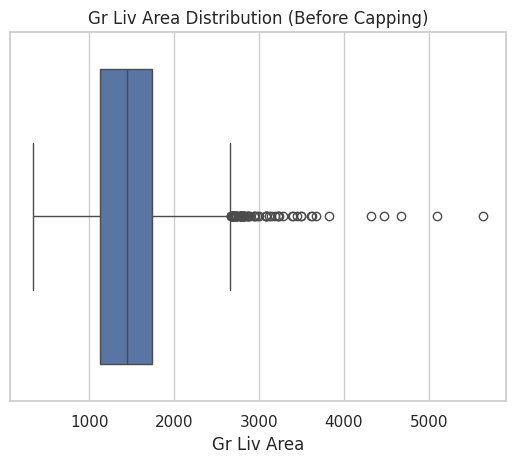

In [158]:
# Let's visualize 'Gr Liv Area' to see outliers
sns.boxplot(x=df_cleaned['Gr Liv Area'])
plt.title('Gr Liv Area Distribution (Before Capping)')
plt.show()

In [159]:
def cap_outliers_iqr(df, column_name):
    """Caps outliers in a specified column using the 1.5*IQR rule."""
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"Capping '{column_name}'... Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f}")

    # np.clip 'caps' the values at the lower and upper bounds
    df[column_name] = np.clip(df[column_name], lower_bound, upper_bound)
    return df

# Cap outliers for 'Gr Liv Area' and 'Lot Area'
df_cleaned = cap_outliers_iqr(df_cleaned, 'Gr Liv Area')
df_cleaned = cap_outliers_iqr(df_cleaned, 'Lot Area')


Capping 'Gr Liv Area'... Lower: 200.88, Upper: 2667.88
Capping 'Lot Area'... Lower: 1267.75, Upper: 17727.75


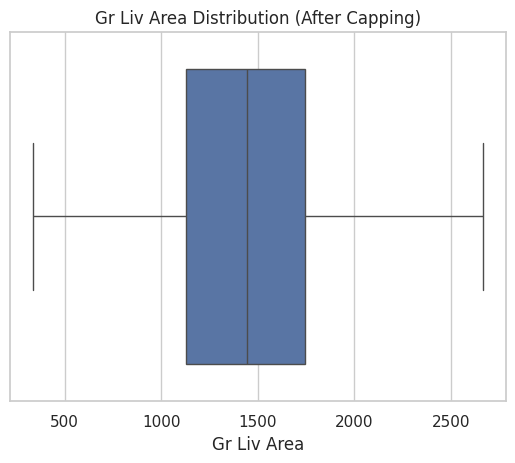

In [160]:
# Visualize 'Gr Liv Area' after capping
sns.boxplot(x=df_cleaned['Gr Liv Area'])
plt.title('Gr Liv Area Distribution (After Capping)')
plt.show()

### Convert Data Types

**Justification:** Sometimes, variables are stored as the wrong type. A common example in this dataset is `MS SubClass`. It's stored as a number (e.g., 20, 60), but it's actually a *categorical code* (e.g., 20 = 1-STORY 1946 & NEWER ALL STYLES). We must convert it to a string (`object`) so it's treated as a category during one-hot encoding, not as a numerical value.

In [161]:
print(f"'MS SubClass' dtype before: {df_cleaned['MS SubClass'].dtype}")

df_cleaned['MS SubClass'] = df_cleaned['MS SubClass'].astype(str)

print(f"'MS SubClass' dtype after: {df_cleaned['MS SubClass'].dtype}")
print(f"Unique 'MS SubClass' values: {df_cleaned['MS SubClass'].unique()}")

'MS SubClass' dtype before: int64
'MS SubClass' dtype after: object
Unique 'MS SubClass' values: ['20' '60' '120' '50' '85' '160' '80' '30' '90' '190' '45' '70' '75' '40'
 '180' '150']


## Save Cleaned Data

The data cleaning is complete. Let's save the cleaned DataFrame to a new CSV file for the next stage (feature engineering and modeling).

In [162]:
# Final check on the cleaned data's info
print("Cleaned Data Info:")
df_cleaned.info()


Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   object 
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2930 non-null   float64
 3   Lot Area         2930 non-null   float64
 4   Street           2930 non-null   object 
 5   Lot Shape        2930 non-null   object 
 6   Land Contour     2930 non-null   object 
 7   Utilities        2930 non-null   object 
 8   Lot Config       2930 non-null   object 
 9   Land Slope       2930 non-null   object 
 10  Neighborhood     2930 non-null   object 
 11  Condition 1      2930 non-null   object 
 12  Condition 2      2930 non-null   object 
 13  Bldg Type        2930 non-null   object 
 14  House Style      2930 non-null   object 
 15  Overall Qual     2930 non-null   int64  
 16  Overall Cond     2930 non-null   int64  


In [163]:
# Save to new file
df_cleaned.to_csv('./data/AmesHousing_cleaned.csv', index=False)

print("\nCleaned data saved to 'AmesHousing_cleaned.csv'")


Cleaned data saved to 'AmesHousing_cleaned.csv'


In [164]:
# Load the dataset
file_name = './data/AmesHousing_cleaned.csv'

## Feature Extraction

Now, let's create new features that might have a stronger relationship with `SalePrice`.

In [165]:
# --- Age-related Features ---
df['Age_at_Sale'] = df['Yr Sold'] - df['Year Built']
df['Remod_Age_at_Sale'] = df['Yr Sold'] - df['Year Remod/Add']
df['Is_Remodeled'] = (df['Year Remod/Add'] != df['Year Built']).astype(int)

# Garage age: set to 0 if no garage (where 'Garage Yr Blt' is 0)
df['Garage_Age_at_Sale'] = 0
df.loc[df['Garage Yr Blt'] > 0, 'Garage_Age_at_Sale'] = df['Yr Sold'] - df.loc[df['Garage Yr Blt'] > 0, 'Garage Yr Blt']

# --- Total Area Features ---
df['Total_SF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']

# --- Total Bathroom Features ---
df['Total_Bath'] = df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath']) + df['Full Bath'] + (0.5 * df['Half Bath'])

# --- Total Porch/Deck Features ---
df['Total_Porch_SF'] = df['Wood Deck SF'] + df['Open Porch SF'] + df['Enclosed Porch'] + df['3Ssn Porch'] + df['Screen Porch']

print("--- Feature Extraction Complete --- ")
new_features = ['Age_at_Sale', 'Remod_Age_at_Sale', 'Is_Remodeled', 'Garage_Age_at_Sale', 'Total_SF', 'Total_Bath', 'Total_Porch_SF']
print(df[new_features].head())

--- Feature Extraction Complete --- 
   Age_at_Sale  Remod_Age_at_Sale  Is_Remodeled  Garage_Age_at_Sale  Total_SF  \
0           50                 50             0                  50    2736.0   
1           49                 49             0                  49    1778.0   
2           52                 52             0                  52    2658.0   
3           42                 42             0                  42    4220.0   
4           13                 12             1                  13    2557.0   

   Total_Bath  Total_Porch_SF  
0         2.0             272  
1         1.0             260  
2         1.5             429  
3         3.5               0  
4         2.5             246  


## Target Variable Transformation

House prices are often right-skewed. Linear models perform better when the target variable is normally distributed. We'll check the distribution of `SalePrice` and apply a log transformation to normalize it.

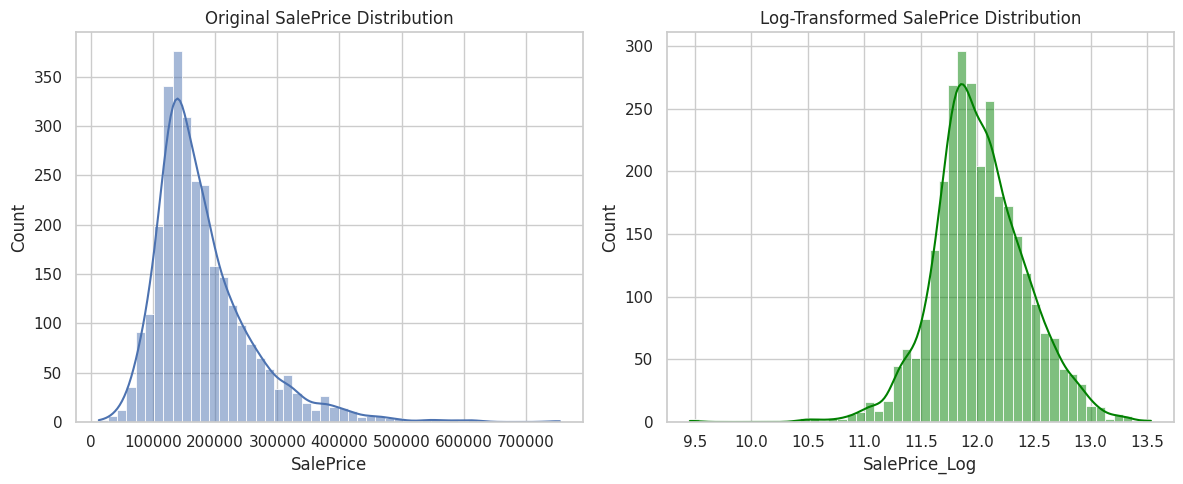

In [166]:
df['SalePrice_Log'] = np.log1p(df['SalePrice'])

# Plotting histograms to show the transformation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True, bins=50)
plt.title('Original SalePrice Distribution')
plt.xlabel('SalePrice')

plt.subplot(1, 2, 2)
sns.histplot(df['SalePrice_Log'], kde=True, bins=50, color='green')
plt.title('Log-Transformed SalePrice Distribution')
plt.xlabel('SalePrice_Log')

plt.tight_layout()
plt.show()

**Observation:**

The original `SalePrice` is heavily right-skewed. The log-transformed `SalePrice_Log` is much closer to a normal distribution. We will use `SalePrice_Log` as our target variable for modeling.

## Scaling (Numerical) & Encoding (Categorical)

We will now prepare the final feature set.
1.  **Scaling**: Numerical features will be scaled using `StandardScaler` so that they all have a mean of 0 and a standard deviation of 1. This is crucial for models like Ridge, Lasso, and SVM.
2.  **Encoding**: Categorical features will be converted into numerical format using One-Hot Encoding (`pd.get_dummies`).

In [167]:
# --- Identify Feature Types ---
target = 'SalePrice_Log'

# Identify all numerical features (original + new)
original_numerical_features = list(df.select_dtypes(include=['int64', 'float64']).columns)

# Define features to remove (targets, and originals of engineered features)
features_to_remove = ['SalePrice', 'SalePrice_Log', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Mo Sold', 'Yr Sold']
numerical_features = [f for f in original_numerical_features if f not in features_to_remove]
numerical_features.append('Is_Remodeled') # Add binary feature
numerical_features = sorted(list(set(numerical_features)))

# Identify all categorical features
categorical_features = sorted(list(df.select_dtypes(include=['object']).columns))

print(f"--- Feature Identification ---")
print(f"Target variable: {target}")
print(f"Total numerical features to scale: {len(numerical_features)}")
print(f"Total categorical features to encode: {len(categorical_features)}")

# --- Apply Transformations ---
df_eng = df.copy()

# 1. Scaling Numerical Features
scaler = StandardScaler()
df_eng[numerical_features] = scaler.fit_transform(df_eng[numerical_features])

print("\n--- Numerical Features Scaled (StandardScaler) --- ")
print("Sample of scaled data:")
print(df_eng[numerical_features].head())

# 2. Encoding Categorical Features
df_eng = pd.get_dummies(df_eng, columns=categorical_features, drop_first=True)

print("\n--- Categorical Features Encoded (One-Hot) --- ")
print(f"New total number of columns: {len(df_eng.columns)}")

--- Feature Identification ---
Target variable: SalePrice_Log
Total numerical features to scale: 40
Total categorical features to encode: 43

--- Numerical Features Scaled (StandardScaler) --- 
Sample of scaled data:
   1st Flr SF  2nd Flr SF  3Ssn Porch  Age_at_Sale  Bedroom AbvGr  \
0    1.267003   -0.783185   -0.103134     0.447923       0.176094   
1   -0.672643   -0.783185   -0.103134     0.414904      -1.032234   
2    0.432445   -0.783185   -0.103134     0.513959       0.176094   
3    2.425687   -0.783185   -0.103134     0.183776       0.176094   
4   -0.590974    0.853432   -0.103134    -0.773756       0.176094   

   Bsmt Full Bath  Bsmt Half Bath  Bsmt Unf SF  BsmtFin SF 1  BsmtFin SF 2  \
0        1.083694       -0.249311    -0.269134      0.431097     -0.293973   
1       -0.822046       -0.249311    -0.658284      0.055696      0.557395   
2       -0.822046       -0.249311    -0.348784      1.054570     -0.293973   
3        1.083694       -0.249311     1.105408      1.36

## Feature Analysis (Correlation & Multicollinearity)

Let's check which features are most correlated with our new target, `SalePrice_Log`. We'll also create a heatmap to check for **multicollinearity** (high correlation *between* predictor features), which can be an issue for simple linear regression.


--- Top 20 Features Correlated with SalePrice_Log ---
SalePrice_Log         1.000000
Overall Qual          0.825645
Total_SF              0.782622
Gr Liv Area           0.695863
Garage Cars           0.675318
Total_Bath            0.665653
Garage Area           0.651132
Total Bsmt SF         0.625099
Year Built            0.615485
1st Flr SF            0.602629
Year Remod/Add        0.586153
Garage Yr Blt         0.580502
Full Bath             0.577335
Foundation_PConc      0.544291
Exter Qual_Gd         0.500054
TotRms AbvGrd         0.492580
Fireplaces            0.488945
BsmtFin Type 1_GLQ    0.457372
Mas Vnr Area          0.448613
Garage Type_Attchd    0.413036
BsmtFin SF 1          0.410801
Name: SalePrice_Log, dtype: float64

--- Bottom 20 Features Correlated with SalePrice_Log ---
Kitchen Qual_Fa        -0.204790
Bsmt Qual_Fa           -0.208054
Roof Style_Gable       -0.209136
Garage Qual_Fa         -0.214455
Neighborhood_IDOTRR    -0.242989
Bsmt Exposure_No       -0.252926
Ne

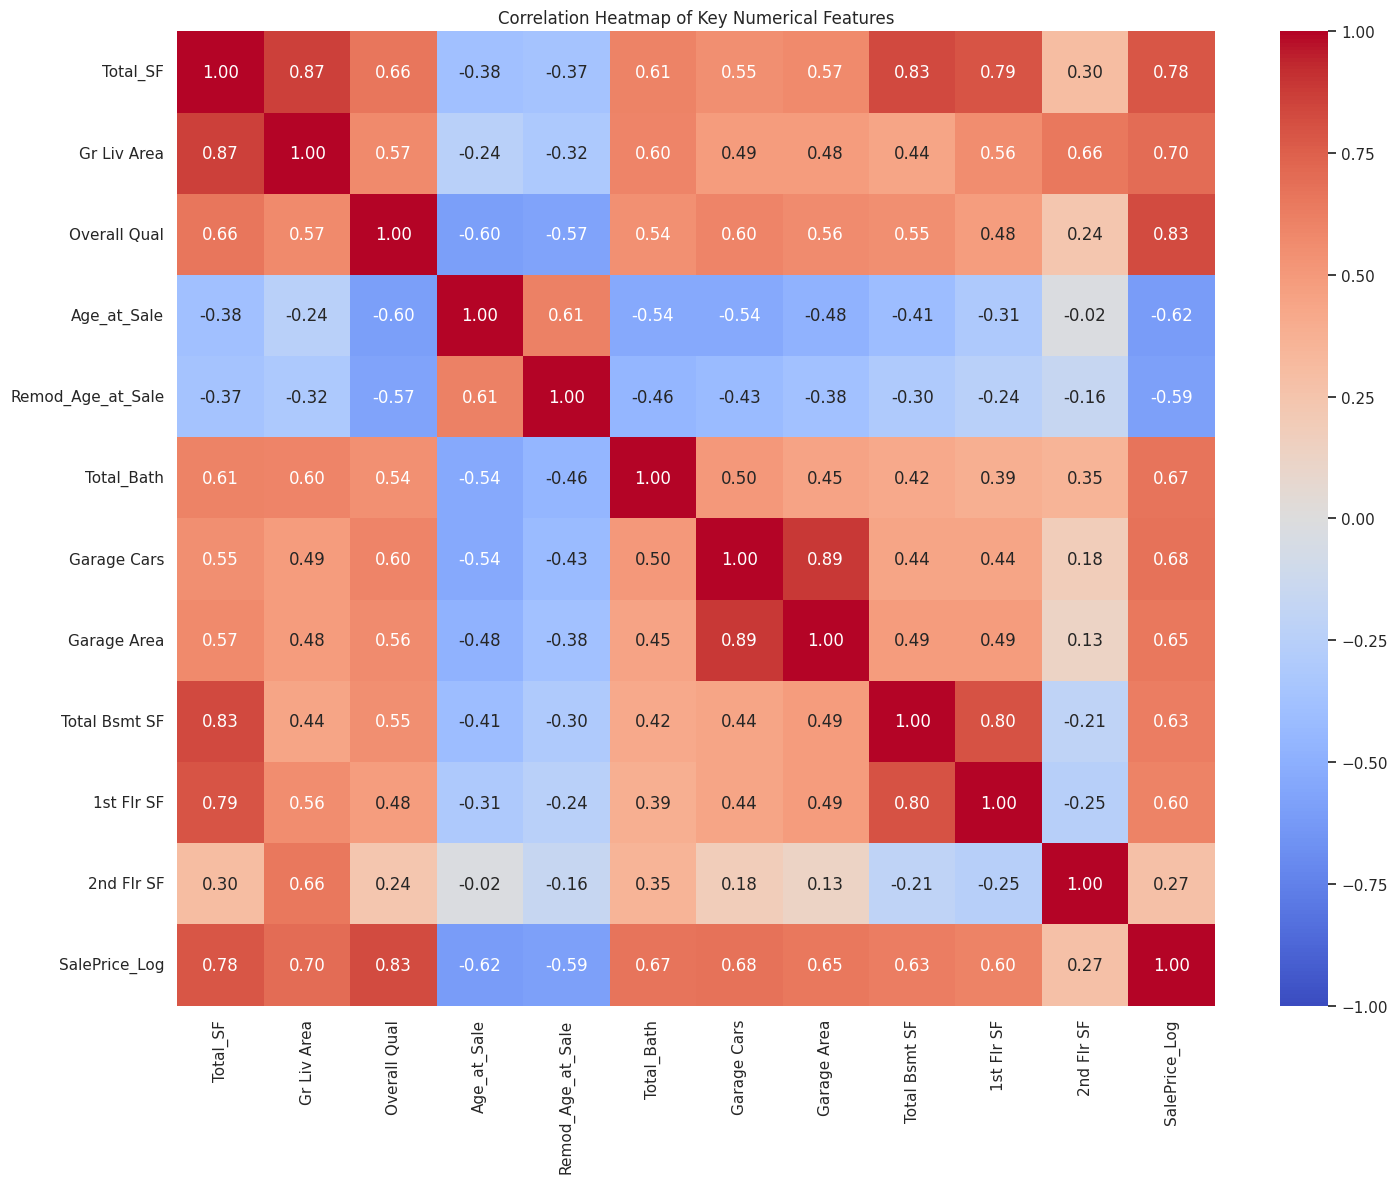

In [168]:
# Calculate correlation with target
# We drop the original 'SalePrice' as 'SalePrice_Log' is our target
correlations = df_eng.drop(columns='SalePrice').corr()[target].sort_values(ascending=False)

print(f"\n--- Top 20 Features Correlated with {target} ---")
print(correlations.head(21)) # Print 21 to exclude target itself (corr=1)

print(f"\n--- Bottom 20 Features Correlated with {target} ---")
print(correlations.tail(20))

# Plot correlation heatmap for key numerical features
plt.figure(figsize=(15, 12))
key_num_features = ['Total_SF', 'Gr Liv Area', 'Overall Qual', 'Age_at_Sale',
                    'Remod_Age_at_Sale', 'Total_Bath', 'Garage Cars', 'Garage Area',
                    'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', target]

sns.heatmap(df_eng[key_num_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.tight_layout()
plt.show()

**Observations:**

* **Top Correlations**: Our new feature `Total_SF` has a very strong positive correlation (0.78) with `SalePrice_Log`, slightly higher than `Gr Liv Area` (0.70). `Overall Qual` remains the strongest predictor (0.83). Our `Total_Bath` feature (0.67) is also a strong predictor. The age features (`Age_at_Sale`, `Garage_Age_at_Sale`) are strongly *negatively* correlated, which makes sense: older houses tend to be cheaper.
* **Multicollinearity**: The heatmap shows high correlation between several predictors. For example:
    * `Total_SF` and `Gr Liv Area` (0.87)
    * `Total_SF` and `Total Bsmt SF` (0.83)
    * `Garage Cars` and `Garage Area` (0.89)
    
This is not a problem for many models, but it's good to be aware of. For a simple Linear Regression, you might drop one feature from each highly correlated pair (e.g., keep `Total_SF` and drop `Gr Liv Area` and `Total Bsmt SF`). For models like **Ridge** or **Lasso** regression, this multicollinearity is handled automatically.

## Save Final Engineered Data

Finally, we'll save the fully engineered dataset. It contains the scaled numerical features, the one-hot encoded categorical features, and the log-transformed target variable. This file is ready for modeling.

In [169]:
# Separate X and y for the final dataset
# X_final contains all 271 engineered features
# y_final contains the log-transformed target
features_to_drop = ['SalePrice', 'SalePrice_Log']
X_final = df_eng.drop(columns=features_to_drop)
y_final = df_eng[target]

# Create final engineered DataFrame by combining features and target
df_final = pd.concat([X_final, y_final], axis=1)

# Save to CSV
output_filename = './data/AmesHousing_engineered.csv'
df_final.to_csv(output_filename, index=False)

print(f"\n--- Final Engineered DataFrame Saved to '{output_filename}' ---")
print(f"Final shape (rows, columns): {df_final.shape}")
print("This file is now ready for model training.")


--- Final Engineered DataFrame Saved to './data/AmesHousing_engineered.csv' ---
Final shape (rows, columns): (2930, 270)
This file is now ready for model training.


## Final Summary

In this notebook, we performed a comprehensive feature engineering pipeline:

1.  **Cleaned Data**: Handled minor NA values and corrected the `Garage Yr Blt` anomaly and `MS SubClass` data type.
2.  **Extracted Features**: Created 7 new features: `Age_at_Sale`, `Remod_Age_at_Sale`, `Is_Remodeled`, `Garage_Age_at_Sale`, `Total_SF`, `Total_Bath`, and `Total_Porch_SF`. These features, especially `Total_SF` and `Total_Bath`, proved to be highly correlated with the target.
3.  **Transformed Target**: Normalized the `SalePrice` variable using `np.log1p()` to create `SalePrice_Log`, which is better suited for linear models.
4.  **Scaled & Encoded**: Standardized all 37 numerical features and one-hot encoded all 40 categorical features.
5.  **Final Dataset**: The resulting dataset, saved as `AmesHousing_engineered.csv`, has **2930 rows** and **270 columns** (270 features + 1 target variable) and is ready for model training.